In [6]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.Collecting scikit-image
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.9 MB 3.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/12.9 MB 4.0 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.9 MB 4.3 MB/s eta 0:00:03
   ---------- ----------------------------- 3.4/12.9 MB 4.4 MB/s eta 0:00:03
   ------------- -------------------------- 4.5/12.9 MB 4.5 MB/s eta 0:00:02
   ----------------- ---------------------- 5.5/12.9 MB 4.5 MB/s eta 0:00:02
   ------------------- -------------------- 6.3/12.9 MB 4.4 MB/s eta 0:00:02
   ---------------------- ----------------- 7.3/12.9 MB 4.5 MB/s eta 0:00:02
   ------------------------ --------------- 7.9/12.9 MB 4.3 MB/s eta 0:00:02
   -------------------------- ------------- 8.7/12.9 MB 4.2 MB/s eta 0:00:02
   ---------------------------- ----------- 9.2/12.9 MB 4.0 MB/s eta 0:


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import generic_filter
from skimage import data, img_as_ubyte

In [8]:
# Utility function to display images
def display_images(images, titles, rows, cols, figsize=(15, 10)):
    plt.figure(figsize=figsize)
    for i in range(len(images)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

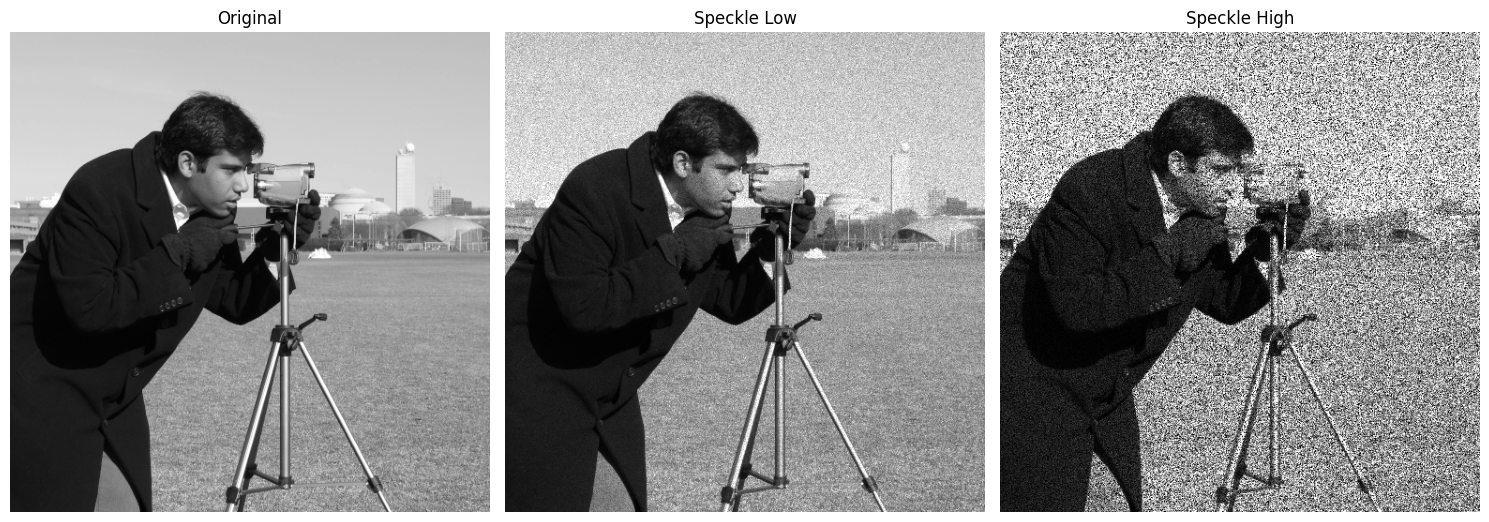

In [9]:
#Part 1: Add Speckle Noise
# Load sample image
original = data.camera()
original = img_as_ubyte(original)

def add_speckle_noise(img, intensity):
    img = img.astype(np.float32) / 255.0
    noise = np.random.normal(0, intensity, img.shape)
    noisy = img + img * noise
    return np.uint8(np.clip(noisy * 255, 0, 255))

# Add different noise intensities
speckle_low = add_speckle_noise(original, 0.1)
speckle_high = add_speckle_noise(original, 0.5)

display_images([original, speckle_low, speckle_high],
               ['Original', 'Speckle Low', 'Speckle High'], 1, 3)


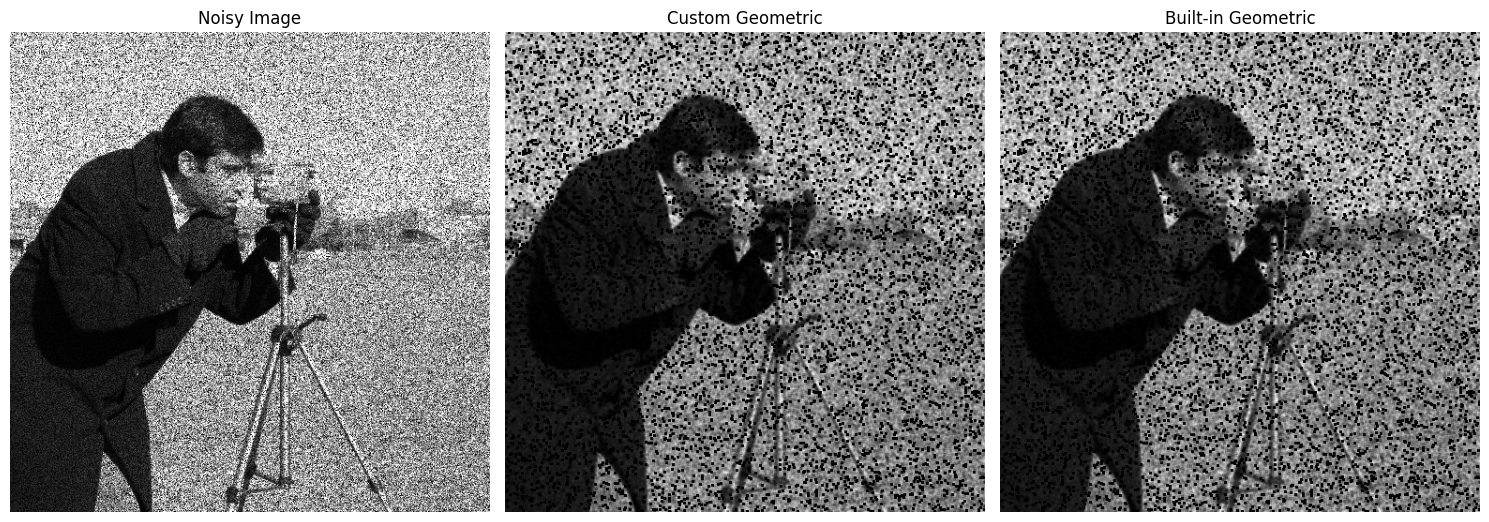

In [10]:
#Part 2: Geometric Mean Filter
def geometric_mean_custom(img, size=3):
    pad = size//2
    img_pad = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    result = np.zeros_like(img, dtype=np.float32)

    for i in range(pad, img_pad.shape[0]-pad):
        for j in range(pad, img_pad.shape[1]-pad):
            window = img_pad[i-pad:i+pad+1, j-pad:j+pad+1].astype(np.float32)
            result[i-pad,j-pad] = np.exp(np.mean(np.log(window + 1e-10)))

    return np.uint8(np.clip(result, 0, 255))

def geometric_mean_builtin(img, size=3):
    def geo_mean(window):
        return np.exp(np.mean(np.log(window + 1e-10)))
    return generic_filter(img.astype(float), geo_mean, size=size)

# Apply filters
geo_custom = geometric_mean_custom(speckle_high)
geo_builtin = geometric_mean_builtin(speckle_high)

display_images([speckle_high, geo_custom, geo_builtin],
               ['Noisy Image', 'Custom Geometric', 'Built-in Geometric'], 1, 3)

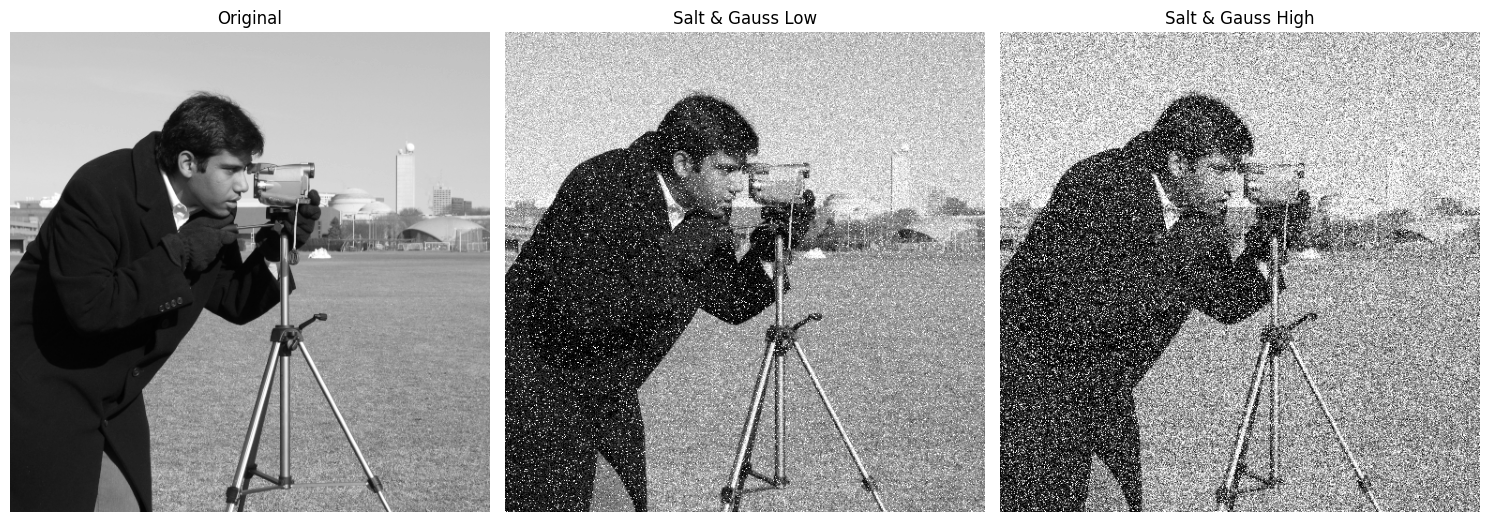

In [11]:
#Part 3: Add Salt & Gaussian Noise
def add_salt_gaussian(img, salt_prob, gaussian_std):
    noisy = img.copy().astype(np.float32)
    # Add Gaussian noise
    noisy += np.random.normal(0, gaussian_std, img.shape)
    # Add salt noise
    salt_mask = np.random.rand(*img.shape) < salt_prob
    noisy[salt_mask] = 255
    return np.uint8(np.clip(noisy, 0, 255))

# Add different noise intensities
salt_gauss_low = add_salt_gaussian(original, 0.05, 25)
salt_gauss_high = add_salt_gaussian(original, 0.1, 50)

display_images([original, salt_gauss_low, salt_gauss_high],
               ['Original', 'Salt & Gauss Low', 'Salt & Gauss High'], 1, 3)

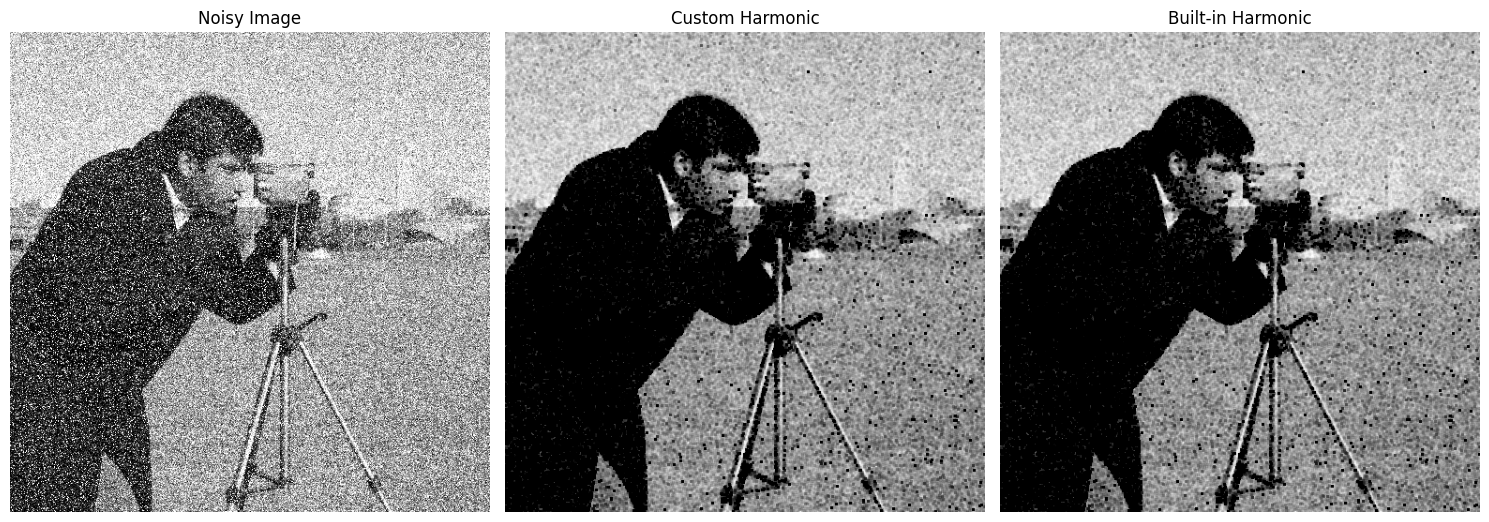

In [12]:
#Part 4: Harmonic Mean Filter
def harmonic_mean_custom(img, size=3):
    pad = size//2
    img_pad = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    result = np.zeros_like(img, dtype=np.float32)

    for i in range(pad, img_pad.shape[0]-pad):
        for j in range(pad, img_pad.shape[1]-pad):
            window = img_pad[i-pad:i+pad+1, j-pad:j+pad+1].astype(np.float32)
            result[i-pad,j-pad] = (size**2) / np.sum(1/(window + 1e-10))

    return np.uint8(np.clip(result, 0, 255))

def harmonic_mean_builtin(img, size=3):
    def harm_mean(window):
        return (size**2) / np.sum(1/(window + 1e-10))
    return generic_filter(img.astype(float), harm_mean, size=size)

# Apply filters
harm_custom = harmonic_mean_custom(salt_gauss_high)
harm_builtin = harmonic_mean_builtin(salt_gauss_high)

display_images([salt_gauss_high, harm_custom, harm_builtin],
               ['Noisy Image', 'Custom Harmonic', 'Built-in Harmonic'], 1, 3)

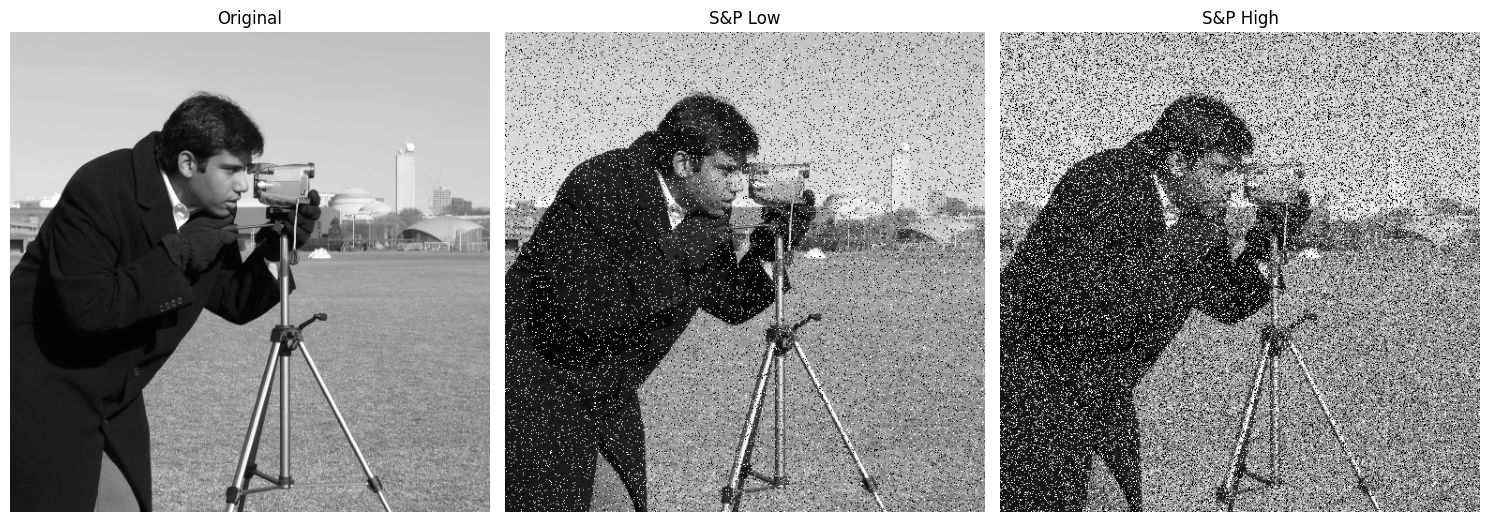

In [13]:
#Part 5: Add Salt & Pepper Noise
def add_salt_pepper(img, prob):
    noisy = img.copy()
    # Salt noise
    salt = np.random.rand(*img.shape) < prob/2
    noisy[salt] = 255
    # Pepper noise
    pepper = np.random.rand(*img.shape) < prob/2
    noisy[pepper] = 0
    return noisy

# Add different noise intensities
sp_low = add_salt_pepper(original, 0.1)
sp_high = add_salt_pepper(original, 0.3)

display_images([original, sp_low, sp_high],
               ['Original', 'S&P Low', 'S&P High'], 1, 3)


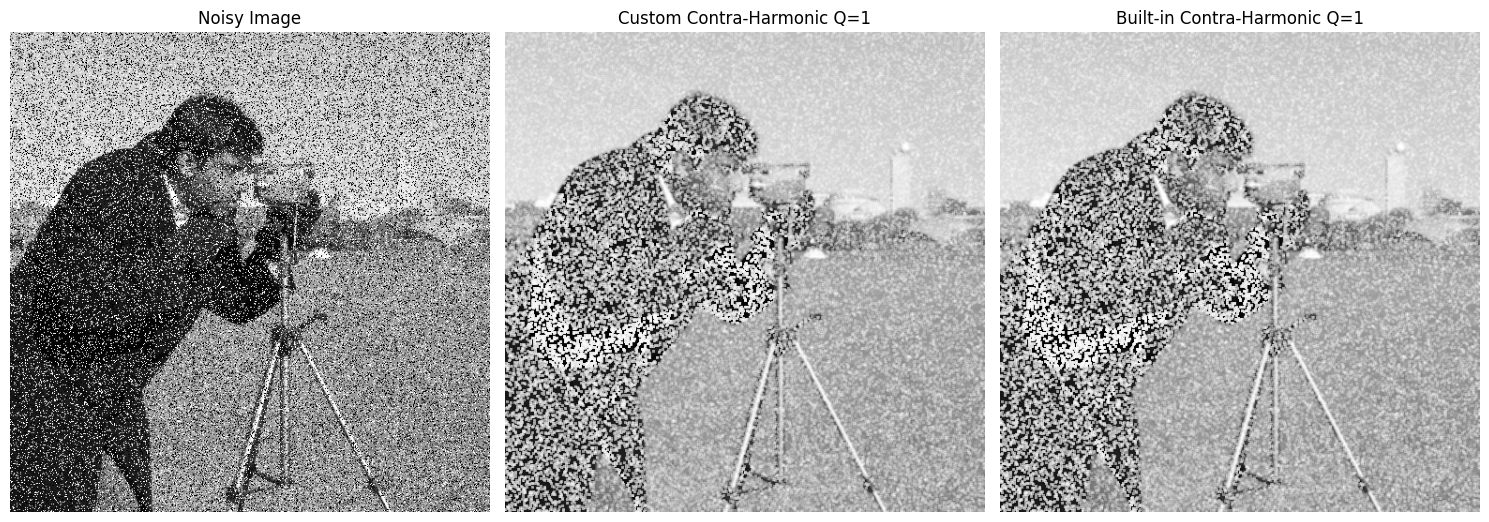

In [14]:
#Part 6: Contra-Harmonic Mean Filter
def contra_harmonic_custom(img, size=3, Q=1):
    pad = size//2
    img_pad = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    result = np.zeros_like(img, dtype=np.float32)

    for i in range(pad, img_pad.shape[0]-pad):
        for j in range(pad, img_pad.shape[1]-pad):
            window = img_pad[i-pad:i+pad+1, j-pad:j+pad+1].astype(np.float32)
            numerator = np.sum(window**(Q+1))
            denominator = np.sum(window**Q) + 1e-10
            result[i-pad,j-pad] = numerator / denominator

    return np.uint8(np.clip(result, 0, 255))

def contra_harmonic_builtin(img, size=3, Q=1):
    def contra_mean(window):
        return np.sum(window**(Q+1)) / (np.sum(window**Q) + 1e-10)
    return generic_filter(img.astype(float), contra_mean, size=size)

# Apply filters (Q=1 for salt noise removal)
contra_custom = contra_harmonic_custom(sp_high, Q=1)
contra_builtin = contra_harmonic_builtin(sp_high, Q=1)

display_images([sp_high, contra_custom, contra_builtin],
               ['Noisy Image', 'Custom Contra-Harmonic Q=1', 'Built-in Contra-Harmonic Q=1'], 1, 3)